In [1]:
from coffea.util import load
from collections import defaultdict

# Load the data from the coffea file
output = load("output.coffea")

# Extract the cutflow information
data = output["cutflow"]["total"]

# Cut names mapping for LaTeX
cut_mapping = {
    'n_lep=2': r'$N_l=2$',
    'leadingLepPT': r'$l_{p_T}^{\text{leading}}>25$',
    'OCLep': r'$\text{OC lepton}$',
    'lepInvariantMass': r'$M_{ll}>20$',
    'onePhoton': r'$N_\gamma=1$',
    'atLeastOneBJet': r'$N_{\text{bjet}}>=1$',
    'eft_val': r'$M_{TT} < \Lambda_{\text{eff}}$'
}

# List of cuts in order
cuts = ['n_lep=2', 'leadingLepPT', 'OCLep', 'lepInvariantMass', 'onePhoton', 'atLeastOneBJet', 'eft_val']

def get_mass_from_sample(sample_name):
    """Extract mass value from sample name"""
    return int(sample_name.split('_')[-1])

def get_sample_group(sample_name):
    """Get sample group (ttaa or Signal)"""
    if sample_name.startswith('ttaa'):
        return 'ttaa'
    elif sample_name.startswith('Signal'):
        return 'Signal'
    return 'unknown'

def generate_table1(data, sample_group, scale_factor=0.70):
    """
    Table 1: Selection efficiency (%) for each cut compared to primary
    Using yield values for proper normalization
    Transposed: Masses as rows, cuts as columns
    """
    # Get samples for this group
    samples = {name: info for name, info in data.items() if get_sample_group(name) == sample_group}
    
    # Sort by mass
    sorted_samples = sorted(samples.items(), key=lambda x: get_mass_from_sample(x[0]))
    
    # Build table header with cuts as columns - using |c| for lines between columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|" + "|".join(["c"] * len(cuts)) + "|}\n\\hline\n"
    header += "Mass (GeV) & " + " & ".join([cut_mapping[cut] for cut in cuts]) + " \\\\ \\hline\n"
    
    # Build rows for each mass
    rows = []
    for sample_name, info in sorted_samples:
        mass = get_mass_from_sample(sample_name)
        row = f"{mass}"
        primary_yield = info['yield']['primary']
        for cut in cuts:
            cut_yield = info['yield'][cut]
            efficiency = (cut_yield / primary_yield) * 100 if primary_yield > 0 else 0
            row += f" & {efficiency:.2f}\\%"
        row += " \\\\ \\hline\n"
        rows.append(row)
    
    footer = "\\end{tabular}\n}\n\\caption{Selection efficiency for " + sample_group + " samples}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_table2(data, sample_group, scale_factor=0.70):
    """
    Table 2: Efficiency of eft_val cut relative to previous cut for each mass
    Using yield values for proper normalization
    Transposed: Masses as rows, single column
    """
    # Get samples for this group
    samples = {name: info for name, info in data.items() if get_sample_group(name) == sample_group}
    
    # Sort by mass
    sorted_samples = sorted(samples.items(), key=lambda x: get_mass_from_sample(x[0]))
    
    # Build table header - using |c|c| for lines between columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|c|}\n\\hline\n"
    header += "Mass (GeV) & $M_{TT} < \\Lambda_{\\text{eff}}$ efficiency \\\\ \\hline\n"
    
    # Build rows for each mass
    rows = []
    for sample_name, info in sorted_samples:
        mass = get_mass_from_sample(sample_name)
        # Get the yield before eft_val cut (atLeastOneBJet)
        previous_cut_yield = info['yield']['atLeastOneBJet']
        eft_val_yield = info['yield']['eft_val']
        efficiency = (eft_val_yield / previous_cut_yield) * 100 if previous_cut_yield > 0 else 0
        rows.append(f"{mass} & {efficiency:.2f}\\% \\\\ \\hline\n")
    
    footer = "\\end{tabular}\n}\n\\caption{Efficiency of $M_{TT} < \\Lambda_{\\text{eff}}$ cut after all previous cuts for " + sample_group + " samples}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_table3(data, scale_factor=0.70):
    """
    Table 3: Ratio of ttaa to (ttaa + Signal) after all selections for each mass
    Using yield values for proper normalization
    Masses as rows, single column
    """
    # Group samples by mass
    mass_groups = defaultdict(dict)
    
    for sample_name, info in data.items():
        mass = get_mass_from_sample(sample_name)
        group = get_sample_group(sample_name)
        if group in ['ttaa', 'Signal']:
            mass_groups[mass][group] = info['yield']['eft_val']
    
    # Sort by mass
    sorted_masses = sorted(mass_groups.keys())
    
    # Build table header - using |c|c| for lines between columns
    header = "\\begin{table}[h]\n\\centering\n"
    header += f"\\scalebox{{{scale_factor}}}{{\n"
    header += "\\begin{tabular}{|c|c|}\n\\hline\n"
    header += "Mass (GeV) & $\\frac{\\text{tt}\\gamma\\gamma}{\\text{tt}\\gamma\\gamma + \\text{Signal}}$ (\\%) \\\\ \\hline\n"
    
    # Build rows
    rows = []
    for mass in sorted_masses:
        if 'ttaa' in mass_groups[mass] and 'Signal' in mass_groups[mass]:
            ttaa = mass_groups[mass]['ttaa']
            signal = mass_groups[mass]['Signal']
            ratio = (ttaa / (ttaa + signal)) * 100 if (ttaa + signal) > 0 else 0
            rows.append(f"{mass} & {ratio:.2f}\\% \\\\ \\hline\n")
    
    footer = "\\end{tabular}\n}\n\\caption{Ratio of tt$\\gamma\\gamma$ events to total events after all selections}\n\\end{table}"
    
    return header + "".join(rows) + footer

def generate_complete_tex_file(data, filename="complete_tables.tex"):
    """
    Generate a complete LaTeX file with all tables in frames
    """
    tex_content = """\\documentclass{beamer}
\\usetheme{default}
\\usepackage{amsmath}
\\usepackage{bm}
\\usepackage{booktabs}
\\usepackage{float}
\\usepackage[caption = false]{subfig}
\\usepackage[]{graphicx}
\\usepackage{adjustbox}

\\title{\\textbf{Analysis Workflow and Results}}
\\subtitle{Single Lepton Channel}

\\begin{document}
\\begin{frame}[plain]
    \\maketitle
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Event Generation - tt$\\gamma\\gamma$ Samples Selection Efficiency}
"""
    
    # Add Table 1a
    tex_content += generate_table1(data, 'ttaa', scale_factor=0.70)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Event Generation - Signal Samples Selection Efficiency}
"""
    
    # Add Table 1b
    tex_content += generate_table1(data, 'Signal', scale_factor=0.7)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Event Generation - $M_{TT} < \\Lambda_{\\text{eff}}$ Efficiency (tt$\\gamma\\gamma$)}
"""
    
    # Add Table 2a
    tex_content += generate_table2(data, 'ttaa', scale_factor=0.75)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Event Generation - $M_{TT} < \\Lambda_{\\text{eff}}$ Efficiency (Signal)}
"""
    
    # Add Table 2b
    tex_content += generate_table2(data, 'Signal', scale_factor=0.75)
    
    tex_content += """
\\end{frame}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\\begin{frame}{Event Generation - tt$\\gamma\\gamma$ / (tt$\\gamma\\gamma$ + Signal) Ratio}
"""
    
    # Add Table 3
    tex_content += generate_table3(data, scale_factor=0.75)
    
    tex_content += """
\\end{frame}

\\end{document}
"""
    
    return tex_content

# Generate and save the complete LaTeX file
tex_content = generate_complete_tex_file(data)
with open("complete_tables.tex", "w") as f:
    f.write(tex_content)

print("Complete LaTeX file has been written to complete_tables.tex")

# Also print individual tables for reference
print("\n" + "=" * 80)
print("TABLE 1a: ttgamma samples - Selection efficiency")
print("=" * 80)
print(generate_table1(data, 'ttaa', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 1b: Signal samples - Selection efficiency")
print("=" * 80)
print(generate_table1(data, 'Signal', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 2a: ttgamma samples - eft_val efficiency")
print("=" * 80)
print(generate_table2(data, 'ttaa', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 2b: Signal samples - eft_val efficiency")
print("=" * 80)
print(generate_table2(data, 'Signal', scale_factor=0.75))

print("\n" + "=" * 80)
print("TABLE 3: ttgamma / (ttgamma + Signal) ratio")
print("=" * 80)
print(generate_table3(data, scale_factor=0.75))

Complete LaTeX file has been written to complete_tables.tex

TABLE 1a: ttgamma samples - Selection efficiency
\begin{table}[h]
\centering
\scalebox{0.75}{
\begin{tabular}{|c|c|c|c|c|c|c|c|}
\hline
Mass (GeV) & $N_l=2$ & $l_{p_T}^{\text{leading}}>25$ & $\text{OC lepton}$ & $M_{ll}>20$ & $N_\gamma=1$ & $N_{\text{bjet}}>=1$ & $M_{TT} < \Lambda_{\text{eff}}$ \\ \hline
500 & 48.09\% & 47.56\% & 47.39\% & 46.91\% & 14.67\% & 14.04\% & 14.04\% \\ \hline
750 & 46.64\% & 45.93\% & 45.75\% & 45.11\% & 15.34\% & 14.64\% & 14.64\% \\ \hline
1000 & 48.66\% & 48.28\% & 48.17\% & 47.73\% & 13.89\% & 13.17\% & 13.17\% \\ \hline
1250 & 49.11\% & 48.83\% & 48.75\% & 48.40\% & 13.55\% & 12.69\% & 12.69\% \\ \hline
1500 & 49.02\% & 48.74\% & 48.67\% & 48.24\% & 13.35\% & 12.39\% & 12.39\% \\ \hline
1750 & 49.61\% & 49.31\% & 49.21\% & 48.77\% & 13.40\% & 12.16\% & 12.16\% \\ \hline
2000 & 49.23\% & 48.99\% & 48.93\% & 48.54\% & 13.15\% & 11.76\% & 11.75\% \\ \hline
2250 & 49.14\% & 48.89\% & 48.82\% & 48.

In [10]:
from coffea.util import load
from collections import defaultdict
import numpy as np

# Load the data from the coffea file
output = load("output.coffea")
MTT_max = []
for smpl in output["MTT_array"]:
    print(smpl, np.max(output["MTT_array"][smpl].value))
    if "Signal_" in smpl:
        MTT_max.append((int(smpl.split("_")[1]), np.max(output["MTT_array"][smpl].value)))

ttaa_3000 9853.23
ttaa_2750 9244.388
ttaa_2500 9034.342
ttaa_2250 8219.112
ttaa_2000 8153.2104
ttaa_1750 6884.1455
ttaa_1500 7333.3457
ttaa_1250 5870.095
ttaa_750 3815.9294
ttaa_500 4918.0293
ttaa_1000 5557.4033
Signal_3000 10331.35
Signal_2750 10034.372
Signal_2500 9686.921
Signal_2250 9887.83
Signal_2000 8491.792
Signal_1750 8629.777
Signal_1500 7374.608
Signal_1250 7420.108
Signal_1000 6036.2544
Signal_750 5426.388
Signal_500 4044.5098


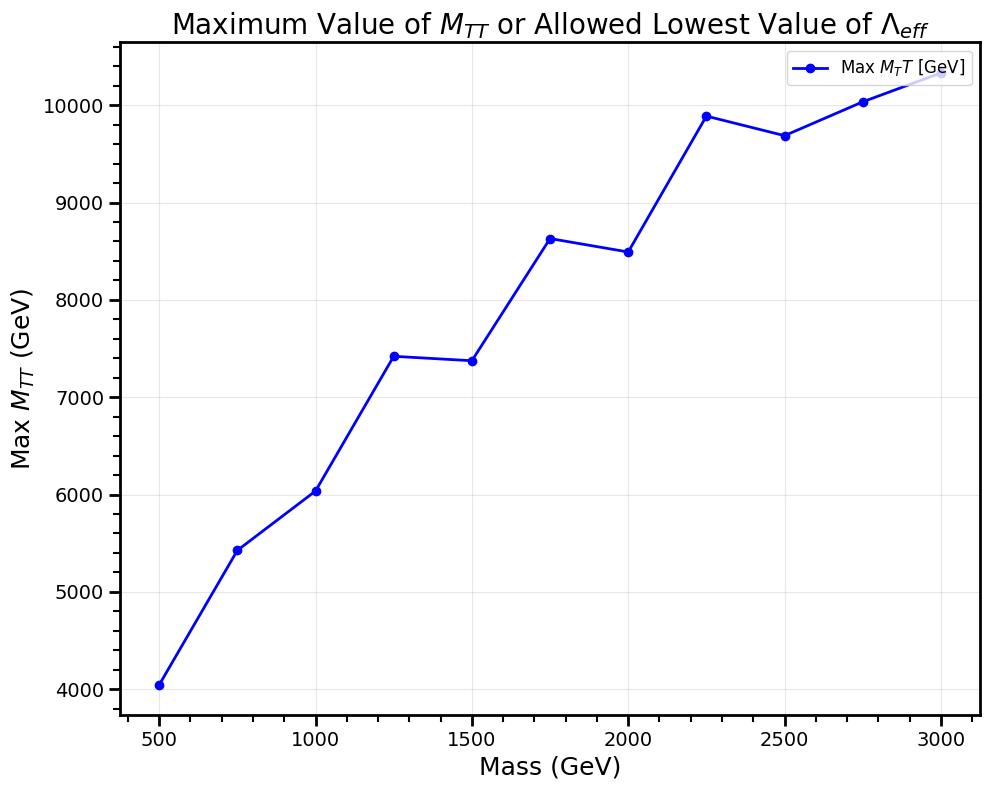

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Unpack your lists
x, y = zip(*MTT_max)  # observed limit (median)

# Create the plot
plt.figure(figsize=(10, 8))


# Plot observed limit
plt.plot(x, y, 'o-', color='Blue', linewidth=2, markersize=6, label='Max $M_TT$ [GeV]')


# Labels and formatting
plt.xlabel('Mass (GeV)', fontsize=18)
plt.ylabel(r'Max $M_{TT}$ (GeV)', fontsize=18)
plt.title(r'Maximum Value of $M_{TT}$ or Allowed Lowest Value of $\Lambda_{eff}$', fontsize=20)

# Set y-scale to log if needed
# plt.yscale('log')

# Grid and ticks
ax = plt.gca()
ax.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=8)
ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=5)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.grid(True, alpha=0.3)

# Legend
plt.legend(loc='upper right', fontsize=12)

# Save and show
plt.tight_layout()
plt.savefig('MTT.png', dpi=150, bbox_inches='tight')
plt.show()